In [1]:
###　CA：Correspondence Analysis
#### Load a scv file aggregated from a specified website or local source and perform CA

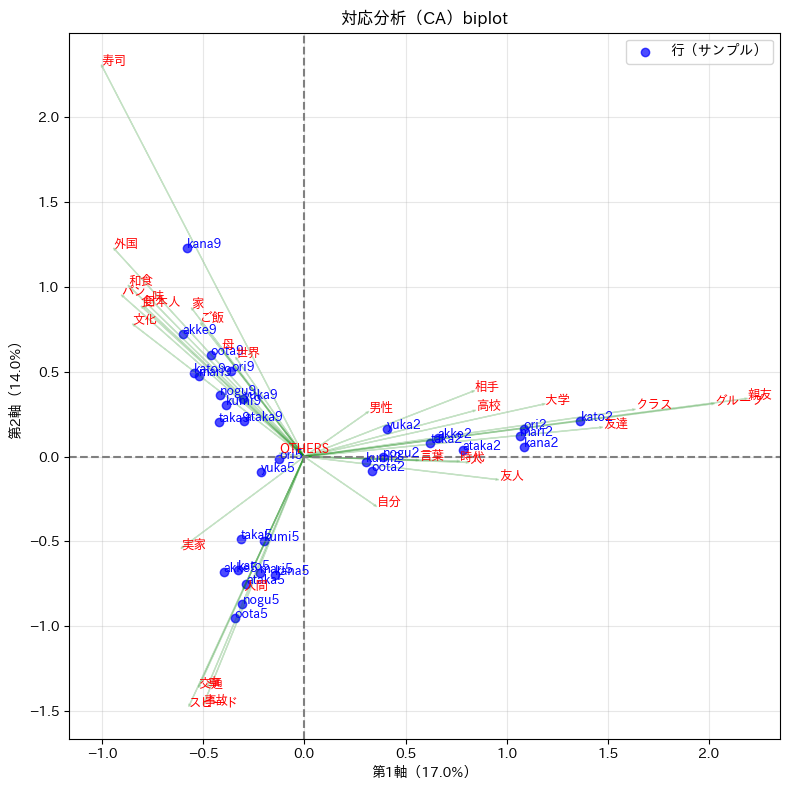

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib


# --- データ読み込み ---
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding="shift-jis")
# --- 第1列をドキュメントラベルとして index にする ---
doc_labels = d1.iloc[:, 0]
# --- 語彙データ（数値データ）を抽出: 第2列〜最後の1列前まで ---
X = d1.iloc[:, 1:]
# --- 行ラベルをドキュメント名に変更 ---
X.index = doc_labels
#X_rel = X.div(X.sum(axis=1), axis=0)

# ============================================================
# df：度数表（行=サンプル、列=カテゴリ）
# ============================================================
# df = あなたの度数表データフレーム
# X = df.copy()
# 行合計・列合計・総計


r = X.sum(axis=1).to_numpy()           # 行和
c = X.sum(axis=0).to_numpy()           # 列和
N = X.values.sum()                     # 総和

# 相対度数行列
P = X / N

# 行比率・列比率
r_hat = P.sum(axis=1).to_numpy()       # 行比率
c_hat = P.sum(axis=0).to_numpy()       # 列比率

# ============================================================
# 対応分析の中心行列（chi-square 残差の標準化）
# ============================================================
# R^(-1/2)
Dr_inv = np.diag(1 / np.sqrt(r_hat + 1e-12))

# C^(-1/2)
Dc_inv = np.diag(1 / np.sqrt(c_hat + 1e-12))

# 基本行列：標準化残差
S = Dr_inv @ (P - np.outer(r_hat, c_hat)) @ Dc_inv

# ============================================================
# SVD（特異値分解）
# ============================================================
U, singular_vals, Vt = np.linalg.svd(S, full_matrices=False)

# 特異値の2乗＝固有値
eigs = singular_vals**2

# ============================================================
# 行スコア・列スコア
# ============================================================

# 行座標
F = Dr_inv @ U[:, :2] @ np.diag(singular_vals[:2])

# 列座標
G = Dc_inv @ Vt.T[:, :2] @ np.diag(singular_vals[:2])

# ============================================================
# 寄与率（分散説明率）
# ============================================================
contrib = eigs / eigs.sum()
pc1_rate = contrib[0] * 100
pc2_rate = contrib[1] * 100

# ============================================================
# BIPLOT（行＝青，列＝赤）
# ============================================================
plt.figure(figsize=(8, 8))

# 行スコア
plt.scatter(F[:, 0], F[:, 1], c="blue", label="行（サンプル）", alpha=0.7)
for i, label in enumerate(X.index):
    plt.text(F[i, 0], F[i, 1], str(label), c="blue", fontsize=9)

# 列スコア（矢印）
for j, label in enumerate(X.columns):
    x, y = G[j, 0], G[j, 1]
    plt.arrow(0, 0, x, y, color="green", alpha=0.2,
              head_width=0.01, length_includes_head=True)
    plt.text(x, y, str(label), c="red", fontsize=9)

plt.axhline(0, ls="--", c="gray")
plt.axvline(0, ls="--", c="gray")
plt.xlabel(f"第1軸（{pc1_rate:.1f}%）")
plt.ylabel(f"第2軸（{pc2_rate:.1f}%）")
plt.title("対応分析（CA）biplot")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
